In [1]:
a=55
a

55

In [3]:
b=4.5
b

4.5

In [5]:
c=44
c

44

In [7]:
d="string"
d

'string'

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']

First 5 samples:
 [[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]

First 5 targets: [0 0 0 0 0]

Model Accuracy: 100.00%


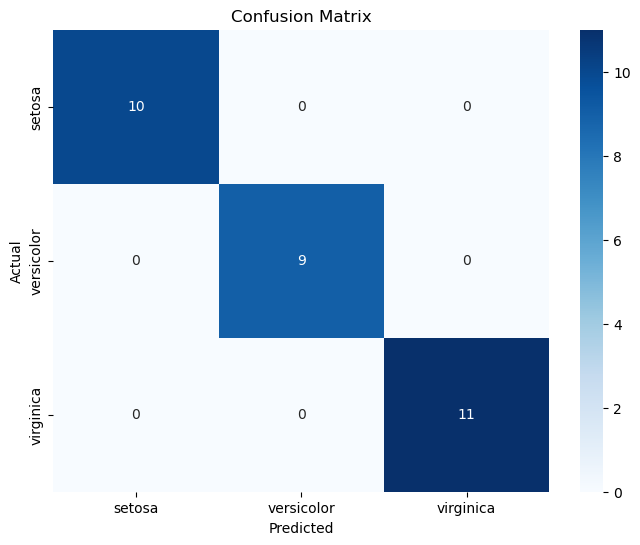


Example Prediction:
Features: [5.1, 3.5, 1.4, 0.2]
Predicted class: setosa
Class probabilities:
setosa: 0.98
versicolor: 0.02
virginica: 0.00


In [9]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns

# Load the Iris dataset
iris = datasets.load_iris()
X = iris.data  # Features (sepal length, sepal width, petal length, petal width)
y = iris.target  # Target (0: setosa, 1: versicolor, 2: virginica)
feature_names = iris.feature_names
target_names = iris.target_names

# Explore the dataset
print("Feature names:", feature_names)
print("Target names:", target_names)
print("\nFirst 5 samples:\n", X[:5])
print("\nFirst 5 targets:", y[:5])

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("\nModel Accuracy: {:.2f}%".format(accuracy * 100))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Example prediction
new_sample = [[5.1, 3.5, 1.4, 0.2]]  # Sample features
predicted_class = model.predict(new_sample)
predicted_prob = model.predict_proba(new_sample)

print("\nExample Prediction:")
print("Features:", new_sample[0])
print("Predicted class:", target_names[predicted_class[0]])
print("Class probabilities:")
for i, prob in enumerate(predicted_prob[0]):
    print(f"{target_names[i]}: {prob:.2f}")

Dataset shape: (20640, 8)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target name: MedHouseVal

First 5 samples:
    MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Target values (first 5): [4.526 3.585 3.521 3.413 3.422]


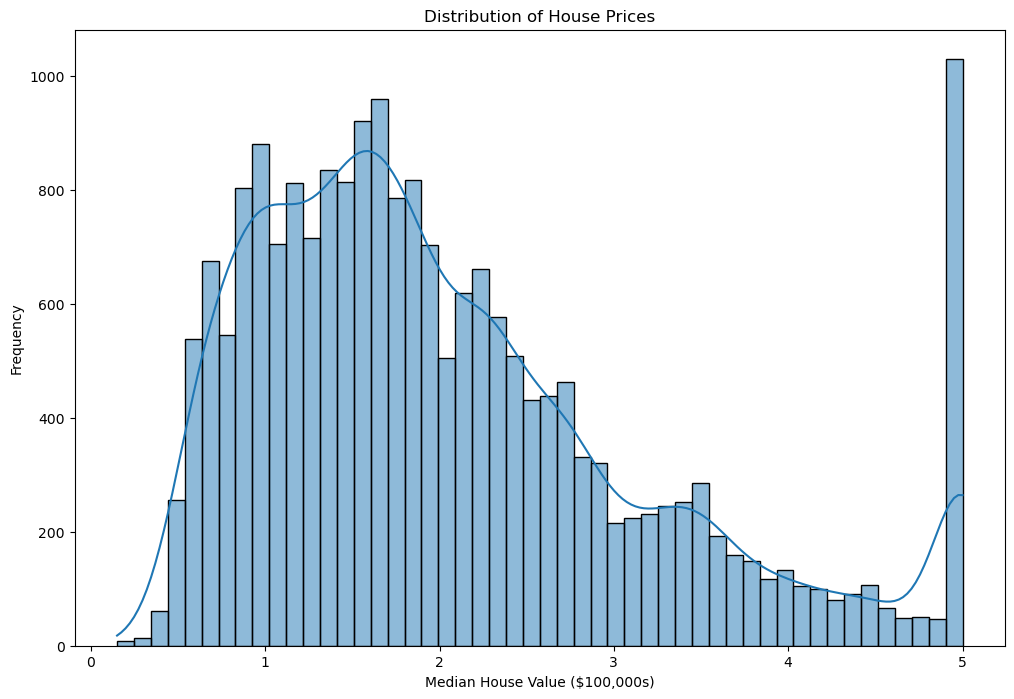

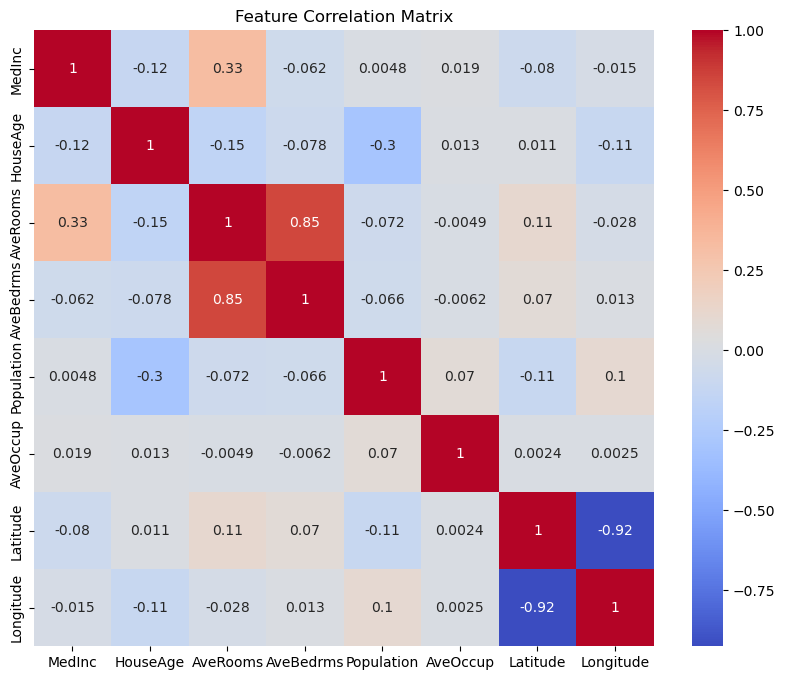

Fitting 5 folds for each of 12 candidates, totalling 60 fits


In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Load the California housing dataset
california = fetch_california_housing()
X = pd.DataFrame(california.data, columns=california.feature_names)
y = california.target
target_name = california.target_names[0]

# Explore the dataset
print("Dataset shape:", X.shape)
print("\nFeature names:", california.feature_names)
print("\nTarget name:", target_name)
print("\nFirst 5 samples:\n", X.head())
print("\nTarget values (first 5):", y[:5])

# Basic EDA
plt.figure(figsize=(12, 8))
sns.histplot(y, bins=50, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Median House Value ($100,000s)')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap
plt.figure(figsize=(10, 8))
corr_matrix = X.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with scaling and model
pipeline = make_pipeline(
    StandardScaler(),
    RandomForestRegressor(random_state=42)
)

# Define hyperparameters for tuning
param_grid = {
    'randomforestregressor__n_estimators': [100, 200],
    'randomforestregressor__max_depth': [None, 10, 20],
    'randomforestregressor__min_samples_split': [2, 5]
}

# Grid search for best parameters
grid_search = GridSearchCV(pipeline, param_grid, cv=5, 
                          scoring='neg_mean_absolute_error',
                          n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best model
best_model = grid_search.best_estimator_
print("\nBest parameters:", grid_search.best_params_)

# Make predictions
y_pred = best_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("\nModel Evaluation:")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R-squared Score: {r2:.4f}")

# Feature importance
feature_importances = best_model.named_steps['randomforestregressor'].feature_importances_
features_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=features_df)
plt.title('Feature Importances')
plt.show()

# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], '--r')
plt.xlabel('Actual Prices ($100,000s)')
plt.ylabel('Predicted Prices ($100,000s)')
plt.title('Actual vs Predicted House Prices')
plt.show()

# Error distribution
errors = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.histplot(errors, bins=50, kde=True)
plt.title('Prediction Error Distribution')
plt.xlabel('Prediction Error ($100,000s)')
plt.show()

# Example prediction
sample_house = X.iloc[0:1].copy()  # Take first house as example
sample_house.loc[:, 'MedInc'] *= 1.2  # Increase income by 20%
predicted_price = best_model.predict(sample_house)
print("\nExample Prediction:")
print("Modified features:")
print(sample_house)
print(f"\nPredicted price: ${predicted_price[0]*100000:,.2f}")
print(f"Original price: ${y[0]*100000:,.2f}")

In [ ]:
a